# Phishing URL Detection - Corrected Evaluation

This notebook uses an untouched final test set. Model selection is performed by stratified cross-validation on the development set, and threshold selection uses out-of-fold predictions from that set. The final test set is evaluated only after both choices are fixed.

## 1. Imports and Reproducibility

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, confusion_matrix
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 2. Data Loading

In [2]:
data_candidates = [
    Path('..') / 'data' / 'phishing.csv',
    Path('data') / 'phishing.csv',
    Path('phishing.csv'),
    Path('/content/phishing.csv'),
]
data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    checked = '\n'.join(f'- {path.resolve()}' for path in data_candidates)
    raise FileNotFoundError(f'phishing.csv was not found. Checked:\n{checked}')

df = pd.read_csv(data_path)
print('Loaded:', data_path.resolve())
display(df.head())

Loaded: /content/phishing.csv


,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,Favicon,NonStdPort,HTTPSDomainURL,RequestURL,AnchorURL,LinksInScriptTags,ServerFormHandler,InfoEmail,AbnormalURL,WebsiteForwarding,StatusBarCust,DisableRightClick,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,1,1,-1,1,0,-1,-1,1,1,0,1,1,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,1,1,-1,1,0,-1,-1,-1,-1,0,1,1,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,1,1,-1,-1,0,0,-1,1,1,0,1,1,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,1,1,1,1,0,0,-1,1,1,0,-1,1,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,1,1,-1,1,0,0,-1,-1,-1,0,1,1,1,1,1,1,1,-1,1,-1,-1,1


## 3. Data Quality and Target Definition

In [3]:
target_col = 'class'
required_columns = {target_col, 'Index'}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f'Missing required columns: {sorted(missing_columns)}')

duplicate_columns = []
for i, column in enumerate(df.columns):
    for previous in df.columns[:i]:
        if df[column].equals(df[previous]):
            duplicate_columns.append((column, previous))
            break

quality_summary = pd.Series({
    'rows': len(df),
    'raw_columns': df.shape[1],
    'missing_values': int(df.isna().sum().sum()),
    'duplicated_rows': int(df.duplicated().sum()),
    'duplicated_columns': len(duplicate_columns),
    'single_value_columns': sum(df[col].nunique(dropna=False) <= 1 for col in df.columns),
})
display(quality_summary.to_frame('value'))
print('Duplicate column pairs:', duplicate_columns)

if not set(df[target_col].dropna().unique()).issubset({-1, 1}):
    raise ValueError('Expected class labels to contain only -1 and 1.')

# Original -1 means phishing. Map phishing to the positive class for intuitive recall/FN.
y = df[target_col].map({-1: 1, 1: 0}).astype(int)
X = df.drop(columns=[target_col, 'Index'])

class_distribution = pd.DataFrame({
    'count': y.value_counts().sort_index(),
    'proportion': y.value_counts(normalize=True).sort_index(),
}).rename(index={0: 'legitimate', 1: 'phishing'})
display(class_distribution)

,value
rows,11054
raw_columns,32
missing_values,0
duplicated_rows,0
duplicated_columns,0
single_value_columns,0


Duplicate column pairs: []


,count,proportion
class,,
legitimate,6157,0.556993
phishing,4897,0.443007


## 4. Exploratory Correlation Analysis

,absolute_spearman_correlation
HTTPS,0.735788
AnchorURL,0.701160
WebsiteTraffic,0.365033
PrefixSuffix-,0.348588
SubDomains,0.304612
RequestURL,0.253478
LinksInScriptTags,0.250893
DomainRegLen,0.225879
ServerFormHandler,0.219150
GoogleIndex,0.129000


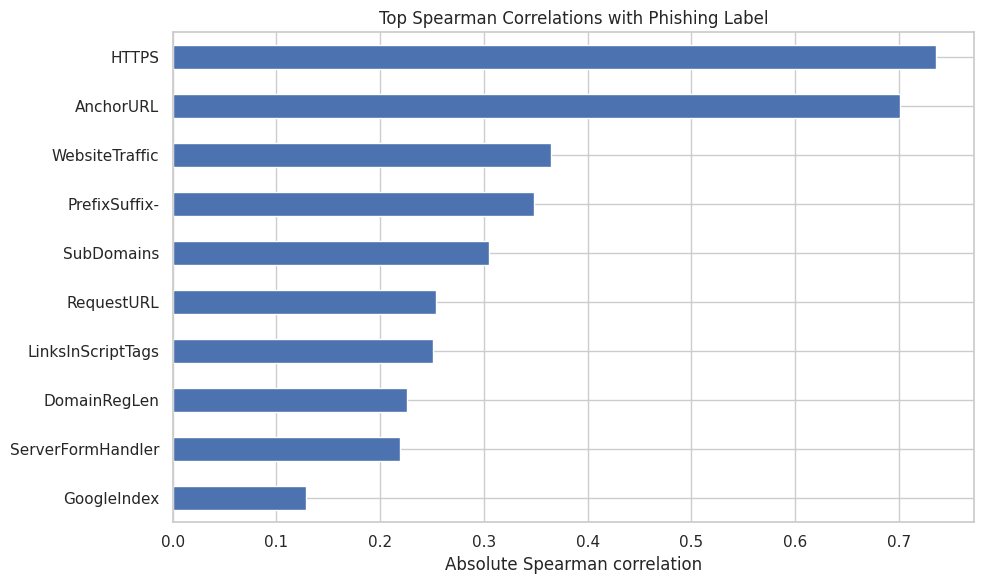

In [4]:
corr = pd.concat([X, y.rename('is_phishing')], axis=1).corr(method='spearman')
top_corr = corr['is_phishing'].drop('is_phishing').abs().sort_values(ascending=False).head(10)
display(top_corr.to_frame('absolute_spearman_correlation'))

plt.figure(figsize=(10, 6))
top_corr.sort_values().plot(kind='barh')
plt.title('Top Spearman Correlations with Phishing Label')
plt.xlabel('Absolute Spearman correlation')
plt.tight_layout()
plt.show()

## 5. Untouched Test Split

The final 20% test set is separated before model or threshold selection. Every selection decision below uses only the 80% development set.

In [5]:
X_development, X_test, y_development, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

split_summary = pd.DataFrame({
    'rows': [len(X_development), len(X_test)],
    'phishing_rate': [y_development.mean(), y_test.mean()],
}, index=['development', 'final_test'])
display(split_summary)

,rows,phishing_rate
development,8843,0.443062
final_test,2211,0.442786


## 6. Model Selection with Cross-Validation

In [6]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight='balanced'
    ),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

cv_rows = []
for name, model in models.items():
    scores = cross_validate(
        model, X_development, y_development, cv=cv, scoring=scoring, n_jobs=-1
    )
    row = {'model': name}
    for metric in scoring:
        values = scores[f'test_{metric}']
        row[f'{metric}_mean'] = values.mean()
        row[f'{metric}_std'] = values.std()
    cv_rows.append(row)

cv_df = pd.DataFrame(cv_rows).sort_values('f1_mean', ascending=False).reset_index(drop=True)
display(cv_df.round(4))

best_model_name = cv_df.loc[0, 'model']
selected_model = clone(models[best_model_name])
print('Selected model:', best_model_name)

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Random Forest,0.9705,0.0010,0.9734,0.0061,0.9597,0.0075,0.9665,0.0013,0.9956,0.0008
1,Gradient Boosting,0.9485,0.0050,0.9509,0.0085,0.9321,0.0045,0.9414,0.0056,0.9898,0.0016
2,Logistic Regression,0.9267,0.0059,0.9283,0.0074,0.9045,0.0112,0.9162,0.0070,0.9787,0.0027


Selected model: Random Forest


## 7. Threshold Selection from Out-of-Fold Predictions

The selected model produces one out-of-fold probability for every development row. The threshold rule prioritizes phishing recall while requiring at least 95% phishing precision. If no candidate meets that floor, the threshold with the highest F1 is used.

In [7]:
development_prob = cross_val_predict(
    selected_model,
    X_development,
    y_development,
    cv=cv,
    method='predict_proba',
    n_jobs=-1,
)[:, 1]

threshold_rows = []
for threshold in np.arange(0.20, 0.81, 0.05):
    pred = (development_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_development, pred).ravel()
    threshold_rows.append({
        'threshold': threshold,
        'precision_phishing': precision_score(y_development, pred),
        'recall_phishing': recall_score(y_development, pred),
        'f1_phishing': f1_score(y_development, pred),
        'phishing_missed': fn,
        'legitimate_blocked': fp,
    })

threshold_df = pd.DataFrame(threshold_rows)
eligible = threshold_df[threshold_df['precision_phishing'] >= 0.95]
if eligible.empty:
    selected_threshold_row = threshold_df.sort_values(
        ['f1_phishing', 'recall_phishing'], ascending=False
    ).iloc[0]
    selection_rule = 'maximum out-of-fold F1 (no threshold met the precision floor)'
else:
    selected_threshold_row = eligible.sort_values(
        ['recall_phishing', 'f1_phishing'], ascending=False
    ).iloc[0]
    selection_rule = 'maximum out-of-fold recall with precision >= 0.95'

selected_threshold = float(selected_threshold_row['threshold'])
display(threshold_df.round(4))
print(f'Selected threshold: {selected_threshold:.2f}')
print('Selection rule:', selection_rule)

,threshold,precision_phishing,recall_phishing,f1_phishing,phishing_missed,legitimate_blocked
0,0.20,0.9161,0.9865,0.9500,53,354
1,0.25,0.9314,0.9811,0.9556,74,283
2,0.30,0.9431,0.9773,0.9599,89,231
3,0.35,0.9538,0.9745,0.9640,100,185
4,0.40,0.9608,0.9704,0.9656,116,155
5,0.45,0.9653,0.9655,0.9654,135,136
6,0.50,0.9733,0.9597,0.9665,158,103
7,0.55,0.9779,0.9505,0.9640,194,84
8,0.60,0.9817,0.9436,0.9623,221,69
9,0.65,0.9855,0.9342,0.9591,258,54


Selected threshold: 0.35
Selection rule: maximum out-of-fold recall with precision >= 0.95


## 8. Final Test Evaluation

In [8]:
final_model = clone(selected_model)
final_model.fit(X_development, y_development)

test_prob = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= selected_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()

final_results = pd.DataFrame([{
    'model': best_model_name,
    'threshold': selected_threshold,
    'accuracy': accuracy_score(y_test, test_pred),
    'precision_phishing': precision_score(y_test, test_pred),
    'recall_phishing': recall_score(y_test, test_pred),
    'f1_phishing': f1_score(y_test, test_pred),
    'mcc': matthews_corrcoef(y_test, test_pred),
    'roc_auc': roc_auc_score(y_test, test_prob),
    'true_positive': tp,
    'true_negative': tn,
    'phishing_missed_FN': fn,
    'legitimate_blocked_FP': fp,
}])
display(final_results.round(4))

confusion_df = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=['actual_legitimate', 'actual_phishing'],
    columns=['predicted_legitimate', 'predicted_phishing'],
)
display(confusion_df)

,model,threshold,accuracy,precision_phishing,recall_phishing,f1_phishing,mcc,roc_auc,true_positive,true_negative,phishing_missed_FN,legitimate_blocked_FP
0,Random Forest,0.35,0.9738,0.9666,0.9745,0.9705,0.9469,0.9966,954,1199,25,33


,predicted_legitimate,predicted_phishing
actual_legitimate,1199,33
actual_phishing,25,954


## 9. Feature Importance

Random Forest and Gradient Boosting expose impurity-based feature importance. For Logistic Regression, absolute standardized coefficients are shown. These values describe model reliance and should not be interpreted as causal effects.

,feature,importance
0,HTTPS,0.3264
1,AnchorURL,0.2421
2,WebsiteTraffic,0.0734
3,SubDomains,0.0639
4,PrefixSuffix-,0.0439
5,LinksInScriptTags,0.0421
6,ServerFormHandler,0.0223
7,RequestURL,0.0194
8,LinksPointingToPage,0.0185
9,DomainRegLen,0.0173


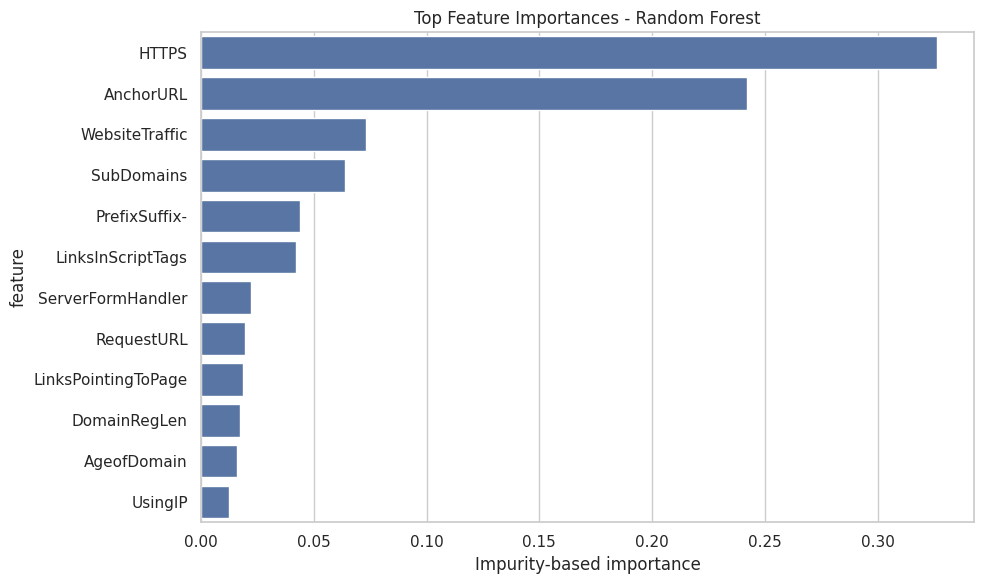

In [9]:
if hasattr(final_model, 'feature_importances_'):
    importances = final_model.feature_importances_
    importance_label = 'impurity-based importance'
else:
    importances = np.abs(final_model.named_steps['model'].coef_[0])
    importance_label = 'absolute standardized coefficient'

feature_importance_df = (
    pd.DataFrame({'feature': X.columns, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(12)
    .reset_index(drop=True)
)
display(feature_importance_df.round(4))

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, y='feature', x='importance')
plt.title(f'Top Feature Importances - {best_model_name}')
plt.xlabel(importance_label.capitalize())
plt.tight_layout()
plt.show()

## 10. Reproducible Conclusion

In [10]:
result = final_results.iloc[0]
print(f'Best model selected by development CV: {best_model_name}')
print(f'Selected decision threshold: {selected_threshold:.2f}')
print(f'Final test F1: {result.f1_phishing:.4f}')
print(f'Final test phishing recall: {result.recall_phishing:.4f}')
print(f'Final test phishing precision: {result.precision_phishing:.4f}')
print(f'Final test ROC-AUC: {result.roc_auc:.4f}')
print(f'Missed phishing URLs (FN): {int(result.phishing_missed_FN)}')
print(f'Legitimate URLs blocked (FP): {int(result.legitimate_blocked_FP)}')
print('The test set remained untouched until the model and threshold were fixed.')

Best model selected by development CV: Random Forest
Selected decision threshold: 0.35
Final test F1: 0.9705
Final test phishing recall: 0.9745
Final test phishing precision: 0.9666
Final test ROC-AUC: 0.9966
Missed phishing URLs (FN): 25
Legitimate URLs blocked (FP): 33
The test set remained untouched until the model and threshold were fixed.
